# Real-world Data Wrangling

This project explores the relationship between football players' attacking performance and their market value. Understanding what drives player valuation is valuable for clubs, scouts, and analysts in making data-driven decisions. To investigate this, two datasets were gathered and wrangled: the first is a CSV dataset from Transfermarkt containing player statistics such as goals, assists, and market value for over 26,000 players. The second is a JSON dataset retrieved from the Sportmonks API containing physical attributes such as height, weight, and date of birth. Together, these datasets allow for a comprehensive analysis of factors that may influence a player's market value.

## Dataset 1
**Type:** CSV files

**Method:** The data was gathered using the manual download method from the "Football Data from Transfermarkt" dataset. Three CSV files were used: players.csv, appearances.csv, and player_valuations.csv. These files were then combined programmatically using pandas merges and aggregation in Python.

**Dataset variables:**

- **name:** The player's name, used to identify each player in the final dataset.
- **goals:** The total number of goals scored by the player.
- **assists:** The total number of assists made by the player.
- **market_value_in_eur:** The player's market value in euros.

In [1]:
import numpy as np
import pandas as pd

df_players = pd.read_csv('players.csv')
df_apps = pd.read_csv('appearances.csv')

df_players.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'international_caps', 'international_goals',
       'current_national_team_id', 'url',
       'current_club_domestic_competition_id', 'current_club_name',
       'market_value_in_eur', 'highest_market_value_in_eur'],
      dtype='object')

In [2]:
df_apps.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played'],
      dtype='object')

In [3]:
df_appearances_agg = df_apps.groupby('player_id').agg({
    'goals': 'sum',
    'assists': 'sum'
}).reset_index()

df_final = pd.merge(
    df_players[['player_id', 'name', 'market_value_in_eur']],
    df_appearances_agg,
    on='player_id',
    how='inner'
).dropna()

df_final = df_final.drop(columns=['player_id'])
df_final.head()

,name,market_value_in_eur,goals,assists
0,Miroslav Klose,1000000.0,48,25
1,Roman Weidenfeller,750000.0,0,0
2,Dimitar Berbatov,1000000.0,38,13
3,Lúcio,200000.0,0,0
4,Tom Starke,100000.0,0,0


In [4]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26493 entries, 0 to 27076
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 26493 non-null  object 
 1   market_value_in_eur  26493 non-null  float64
 2   goals                26493 non-null  int64  
 3   assists              26493 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.0+ MB


## Dataset 2
**Type:** JSON data retrieved from an API

**Method:** The data was gathered programmatically using the Sportmonks Football API through an HTTP request in Python with the requests library. The raw API response was stored locally for reproducibility.

**Dataset variables:**

- **name:** The player's full name.
- **date_of_birth:** The player's date of birth.
- **height:** The player's height.
- **weight:** The player's weight.

In [5]:
import requests

api_token = "X3BAmOWyHQOHHRbarAn0GPXz6cKtZULVcuJV4naOQExmScU5hwTSHfJU2LoU"

all_players = []
page = 1

while len(all_players) < 500:
    url = f"https://api.sportmonks.com/v3/football/players?api_token={api_token}&page={page}"
    response = requests.get(url)
    data = response.json()
    
    if not data.get('data'):
        break
        
    all_players.extend(data['data'])
    page += 1

df_api = pd.DataFrame(all_players)
print(len(df_api))

500


In [6]:
import json

with open('players_api_raw.json', 'w') as f:
    json.dump(data, f)

## Assessing

In [7]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26493 entries, 0 to 27076
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 26493 non-null  object 
 1   market_value_in_eur  26493 non-null  float64
 2   goals                26493 non-null  int64  
 3   assists              26493 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.0+ MB


In [8]:
df_final.describe()

,market_value_in_eur,goals,assists
count,2.649300e+04,26493.000000,26493.000000
mean,2.018114e+06,6.572113,5.174197
std,7.127316e+06,17.353095,11.497351
min,1.000000e+04,0.000000,0.000000
25%,1.500000e+05,0.000000,0.000000
50%,3.000000e+05,1.000000,1.000000
75%,9.000000e+05,5.000000,5.000000
max,2.000000e+08,525.000000,224.000000


In [9]:
df_final.isnull().sum()

name                   0
market_value_in_eur    0
goals                  0
assists                0
dtype: int64

In [10]:
df_final.duplicated().sum()

7

In [11]:
df_api.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    500 non-null    int64  
 1   sport_id              500 non-null    int64  
 2   country_id            500 non-null    int64  
 3   nationality_id        500 non-null    int64  
 4   city_id               293 non-null    float64
 5   position_id           449 non-null    float64
 6   detailed_position_id  214 non-null    float64
 7   type_id               500 non-null    int64  
 8   common_name           500 non-null    object 
 9   firstname             500 non-null    object 
 10  lastname              500 non-null    object 
 11  name                  500 non-null    object 
 12  display_name          500 non-null    object 
 13  image_path            500 non-null    object 
 14  height                496 non-null    float64
 15  weight                4

In [12]:
df_api.describe()

,id,sport_id,country_id,nationality_id,city_id,position_id,detailed_position_id,type_id,height,weight
count,500.000000,500.0,500.000000,500.000000,293.000000,449.000000,214.000000,500.000000,496.000000,482.000000
mean,2253.296000,1.0,716.688000,1267.818000,54287.846416,40.993318,139.280374,40.448000,182.455645,77.072614
std,1369.259369,0.0,956.679035,9669.465083,28197.597166,52.405718,48.972598,51.430706,6.737356,7.942943
min,14.000000,1.0,2.000000,2.000000,165.000000,24.000000,24.000000,24.000000,163.000000,58.000000
25%,953.000000,1.0,455.000000,455.000000,35533.000000,25.000000,149.000000,25.000000,178.000000,72.000000
50%,2339.500000,1.0,462.000000,462.000000,52105.000000,26.000000,151.000000,26.000000,183.000000,76.000000
75%,3473.000000,1.0,1161.000000,1161.000000,78328.000000,27.000000,154.000000,27.000000,188.000000,82.000000
max,4631.000000,1.0,14837.000000,213370.000000,101460.000000,221.000000,226.000000,221.000000,201.000000,98.000000


In [13]:
df_api.isnull().sum()

id                        0
sport_id                  0
country_id                0
nationality_id            0
city_id                 207
position_id              51
detailed_position_id    286
type_id                   0
common_name               0
firstname                 0
lastname                  0
name                      0
display_name              0
image_path                0
height                    4
weight                   18
date_of_birth             0
gender                    0
dtype: int64

In [14]:
df_api.duplicated().sum()

0

In [15]:
df_api[['name', 'date_of_birth', 'height', 'weight']].head(10)

,name,date_of_birth,height,weight
0,Daniel Munthe Agger,1984-12-12,191.0,84.0
1,Liam Miller,1981-02-13,170.0,66.0
2,Anthony Stokes,1988-07-25,180.0,70.0
3,Jermain Defoe,1982-10-07,171.0,65.0
4,Craig Gordon,1982-12-31,193.0,85.0
5,Ross Wallace,1985-05-23,167.0,63.0
6,Nicklas Bendtner,1988-01-16,193.0,84.0
7,Kolo Habib Touré,1981-03-19,180.0,74.0
8,Bernard Mendy,1981-08-20,180.0,77.0
9,Daryl Murphy,1983-03-15,191.0,88.0


In [16]:
df_api['date_of_birth'].dtype

dtype('O')

In [17]:
df_api.columns

Index(['id', 'sport_id', 'country_id', 'nationality_id', 'city_id',
       'position_id', 'detailed_position_id', 'type_id', 'common_name',
       'firstname', 'lastname', 'name', 'display_name', 'image_path', 'height',
       'weight', 'date_of_birth', 'gender'],
      dtype='object')

### Quality Issue 1: Presence of extreme outliers in goals and assists

In [18]:
df_final.describe()

,market_value_in_eur,goals,assists
count,2.649300e+04,26493.000000,26493.000000
mean,2.018114e+06,6.572113,5.174197
std,7.127316e+06,17.353095,11.497351
min,1.000000e+04,0.000000,0.000000
25%,1.500000e+05,0.000000,0.000000
50%,3.000000e+05,1.000000,1.000000
75%,9.000000e+05,5.000000,5.000000
max,2.000000e+08,525.000000,224.000000


In [19]:
df_final[['goals', 'assists']].max()

goals      525
assists    224
dtype: int64

The dataset contains extreme values in the goals and assists columns (e.g., goals reaching 525 and assists up to 224), which are unusually high for football players. These outliers may distort analysis results such as averages and correlations. The issue was identified using `.describe()` to observe distribution statistics and `.max()` to confirm extreme values.

### Quality Issue 2: Market value distribution is highly skewed

In [20]:
df_final['market_value_in_eur'].max()

200000000.0

The market_value_in_eur column shows a very wide range (from 10,000 to 200,000,000), indicating a highly skewed distribution. This may affect statistical analysis and visualizations. The issue was identified using summary statistics, particularly the large difference between minimum, median, and maximum values.

### Tidiness Issue 1: Multiple name columns in df_api

In [21]:
df_api[['common_name', 'firstname', 'lastname', 'name', 'display_name']].head()

,common_name,firstname,lastname,name,display_name
0,D. Agger,Daniel Munthe,Agger,Daniel Munthe Agger,Daniel Agger
1,L. Miller,Liam,Miller,Liam Miller,Liam Miller
2,A. Stokes,Anthony,Stokes,Anthony Stokes,Anthony Stokes
3,J. Defoe,Jermain,Defoe,Jermain Defoe,Jermain Defoe
4,Craig Gordon,Craig,Gordon,Craig Gordon,Craig Gordon


The df_api dataset contains multiple columns representing the same variable (player name): common_name, firstname, lastname, name, and display_name. This violates the tidiness rule that each variable should form one column. The issue was identified by inspecting the column names and comparing their content."

### Tidiness Issue 2: Multiple observational units

In [22]:
df_players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [23]:
df_apps.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [24]:
df_final.head()

,name,market_value_in_eur,goals,assists
0,Miroslav Klose,1000000.0,48,25
1,Roman Weidenfeller,750000.0,0,0
2,Dimitar Berbatov,1000000.0,38,13
3,Lúcio,200000.0,0,0
4,Tom Starke,100000.0,0,0


Tidiness Issue 2 was addressed during the gathering stage. Appearances were aggregated by player before merging, ensuring each row represents one player rather than one match appearance.

## Cleaning

In [25]:
df_clean = df_final.copy()
df_api_clean = df_api.copy()

### Quality Issue 1: Outliers in goals and assists

In [26]:
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_clean = remove_outliers(df_clean, 'goals')
df_clean = remove_outliers(df_clean, 'assists')
df_clean[['goals', 'assists']].describe()

,goals,assists
count,20859.000000,20859.000000
mean,1.491107,1.202263
std,2.449324,1.774107
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,2.000000
max,12.000000,7.000000


In [27]:
# Clean df_api: convert date_of_birth and keep relevant columns
df_api_clean['date_of_birth'] = pd.to_datetime(df_api_clean['date_of_birth'])
df_api_clean = df_api_clean[['name', 'date_of_birth', 'height', 'weight']]

Extreme outliers in goals and assists were removed using the IQR method through a reusable function. This approach was chosen because it provides a consistent and systematic way to reduce the impact of unusually large values that may distort the analysis.

After cleaning, the maximum values were reduced to more reasonable levels, with goals capped at 12 and assists capped at 7.

### Quality Issue 2: Skewed market value

In [28]:
df_clean['market_value_in_eur'] = np.log1p(df_clean['market_value_in_eur'])
df_clean['market_value_in_eur'].describe()

count    20859.000000
mean        12.654323
std          1.388006
min          9.210440
25%         11.736077
50%         12.429220
75%         13.384729
max         18.315320
Name: market_value_in_eur, dtype: float64

In [29]:
# Drop missing values from api clean dataset
df_api_clean = df_api_clean.dropna()
df_api_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   name           482 non-null    object        
 1   date_of_birth  482 non-null    datetime64[ns]
 2   height         482 non-null    float64       
 3   weight         482 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 18.8+ KB


In [30]:
df_api_clean.head()

,name,date_of_birth,height,weight
0,Daniel Munthe Agger,1984-12-12,191.0,84.0
1,Liam Miller,1981-02-13,170.0,66.0
2,Anthony Stokes,1988-07-25,180.0,70.0
3,Jermain Defoe,1982-10-07,171.0,65.0
4,Craig Gordon,1982-12-31,193.0,85.0


A log transformation was applied to `market_value_in_eur` using `np.log1p()` to reduce skewness and make the distribution more suitable for analysis. This was necessary because the original values were highly uneven and spread across a very large range.

### Tidiness Issue 1: Drop redundant name columns, keep only 'name'

In [31]:

df_api_clean = df_api_clean.drop(columns=['common_name', 'firstname', 'lastname', 'display_name'], errors='ignore')
df_api_clean.columns

Index(['name', 'date_of_birth', 'height', 'weight'], dtype='object')

Redundant name columns were dropped from df_api, keeping only the 'name' column. This ensures each variable is represented by a single column

In [32]:

df_clean = df_clean.rename(columns={'market_value_in_eur': 'market_value'})

### Tidiness Issue 2: Add contribution column

In [33]:
df_clean['contribution'] = df_clean['goals'] + df_clean['assists']
df_clean.head()

,name,market_value,goals,assists,contribution
1,Roman Weidenfeller,13.527830,0,0,0
3,Lúcio,12.206078,0,0,0
4,Tom Starke,11.512935,0,0,0
5,Dedê,12.899222,1,2,3
6,Christoph Metzelder,14.220976,0,1,1


Tidiness Issue 2 was addressed during the gathering stage. Appearances were aggregated by player before merging, ensuring each row represents one player rather than one match appearance. The `contribution` column was added as a derived feature to support further analysis.

## Data Storage

In [34]:
# Raw
df_final.to_csv('raw_data.csv', index=False)

# Clean
df_clean.to_csv('cleaned_data.csv', index=False)

df_api.to_csv('api_players_raw.csv', index=False)
df_api_clean.to_csv('api_players_clean.csv', index=False)

The raw and cleaned datasets were stored locally using informative file names. The original merged dataset was saved as `raw_data.csv`, the cleaned dataset was saved as `cleaned_data.csv`, the raw API data was saved as `api_players_raw.csv`, and the cleaned API data was saved as `api_players_clean.csv`. This preserves both raw and cleaned versions of the data and supports reproducibility.

## Answering the Research Question

### Is there a relationship between a player's attacking performance (goals and assists) and their market value?

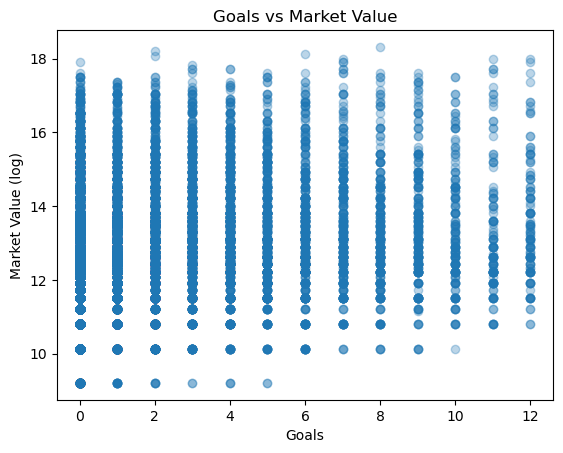

In [35]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['goals'], df_clean['market_value'], alpha=0.3)
plt.xlabel('Goals')
plt.ylabel('Market Value (log)')
plt.title('Goals vs Market Value')
plt.show()

The first visualization shows a positive relationship between goals and market value. In general, players who score more goals tend to have higher market values, although the relationship is not very strong. This suggests that attacking performance contributes to player value, but it is not the only factor affecting market value.

### Do assists have a similar impact on a player's market value as goals?

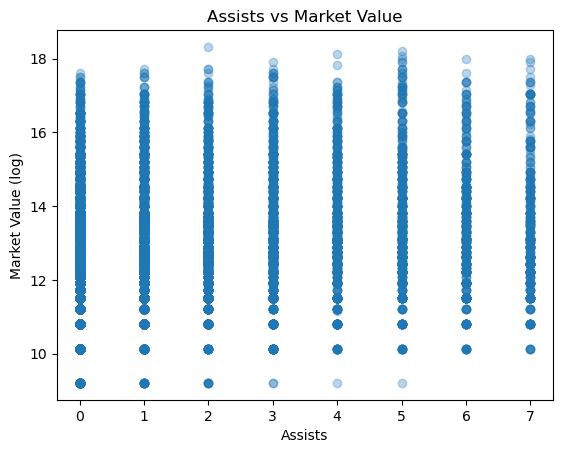

In [36]:
plt.scatter(df_clean['assists'], df_clean['market_value'], alpha=0.3)
plt.xlabel('Assists')
plt.ylabel('Market Value (log)')
plt.title('Assists vs Market Value')
plt.show()

In [37]:
df_clean[['goals', 'assists', 'market_value']].corr()

,goals,assists,market_value
goals,1.000000,0.584472,0.233296
assists,0.584472,1.000000,0.246269
market_value,0.233296,0.246269,1.000000


Both goals and assists show a positive relationship with market value. The correlation between assists and market value (0.246269) is slightly higher than that of goals (0.233296). This suggests that both metrics contribute to player valuation, but neither alone is a strong predictor of market value.

If I had more time, I would explore additional factors affecting market value such as age and player position. I would also improve data cleaning, especially handling outliers, and use more advanced analysis techniques to better understand the relationships between variables.